# TiranaFly — Geospatial Infrastructure & Map Modeling
## Logistics Optimization for TiranaFly — Drone Delivery Network, Tirana

**Course:** Discrete Structures & Algorithms — Project #1  
**Professor:** Prof. Dr. Fatos Xhafa  
**Semester:** 2, 2026

---

### Module Purpose
This notebook builds the **complete geospatial foundation** for the TiranaFly drone delivery network.  
It covers every step needed before routing or fleet optimization can begin:

| Step | Task |
|------|------|
| 0 | Import libraries |
| 1 | Define the Tirana coordinate grid & drone parameters |
| 2 | Partition Tirana into **8 real-world zones** (North, East, South-East, Center, West, South-West, South, South-East Outer) |
| 3 | Place **depots** (zones 1=North, 3=South-East, 5=West, 7=South each get a depot) and generate **16 clients per zone** |
| 4 | Compute Euclidean edge weights |
| 5 | Build a **complete weighted graph** per zone — ready for Dijkstra in the next module |
| 6 | Visualise the map (geometry mirrors the real Tirana district layout) |
| 7 | Export node/edge tables for the routing and fleet modules |

> **Drone spec (shared constants):** max payload **4.0 kg**, max range **D_MAX = 15 km**.


---
## Step 0 — Install & Import Libraries

In [1]:
# ─── Required libraries ────────────────────────────────────────────────────────
# Uncomment the line below if running for the first time in a fresh environment:
# !pip install networkx matplotlib numpy pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import networkx as nx
import math, random
import tkinter as tk

# Fix random seed so results are reproducible across all team members
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## Step 1 — Tirana Coordinate Grid & Drone Parameters

Tirana is modelled as a **20 km × 20 km** 2-D plane:
- `x` ∈ [0, 20] km  →  West to East  
- `y` ∈ [0, 20] km  →  South to North  
- City centre (used as the geometric anchor): **(10, 10)**

### Drone specification
| Parameter | Value | Unit |
|-----------|-------|------|
| Max flight range D_MAX | 15.0 | km |
| Max payload | 4.0 | kg |

A delivery route is **feasible** only when its total Euclidean length ≤ D_MAX.  
Battery consumed = k × distance (linear model).


In [2]:
# ─── Tirana Grid ──────────────────────────────────────────────────────────────
GRID_MIN_X, GRID_MAX_X = 0, 20   # km, West → East
GRID_MIN_Y, GRID_MAX_Y = 0, 20   # km, South → North
CENTER_X = (GRID_MAX_X + GRID_MIN_X) / 2   # 10.0
CENTER_Y = (GRID_MAX_Y + GRID_MIN_Y) / 2   # 10.0

# ─── Drone Parameters (shared across all project modules) ─────────────────────
D_MAX        = 15.0   # Maximum drone flight range (km)
MAX_PAYLOAD  = 4.0    # Maximum cargo weight per flight (kg)

print(f"Grid : x ∈ [{GRID_MIN_X}, {GRID_MAX_X}] km  |  y ∈ [{GRID_MIN_Y}, {GRID_MAX_Y}] km")
print(f"Centre: ({CENTER_X}, {CENTER_Y})")
print(f"Drone : D_MAX={D_MAX} km | Payload={MAX_PAYLOAD} kg")


Grid : x ∈ [0, 20] km  |  y ∈ [0, 20] km
Centre: (10.0, 10.0)
Drone : D_MAX=15.0 km | Payload=4.0 kg


---
## Step 2 — Zone Partitioning: 8 Real-World Districts

The city is divided into the **8 official administrative zones** of Tirana  
(matching the "Tirana – 8 Neighborhood" map):

| # |  Area | Area share | Neighbourhoods |
|---|---------|-----------|----------------|
| 1 | North | 17.2 % | Bërxullë, Kashar, Yzberisht |
| 2 | East | 16.8 % | Dajt, Paskuqan, Shën Koll |
| 3 | South-East | 14.3 % | Liqeni Artificial, Selitë, Kombinat |
| 4 | Centre | 15.5 % | Sheshi Skënderbej, Blloku, Pazari i Ri |
| 5 | West | 13.1 % | Kashar, Vaqarr, Mezez |
| 6 | South-West | 11.8 % | Laprakë, Don Bosko, Ali Demi |
| 7 | South | 10.6 % | Komuna e Parisit, Myslym Shyri, Kodra e Diellit |
| 8 | South-East outer | 10.7 % | Farkë, Qesarak, Petrelë |

Each zone is represented as a **convex polygon** whose vertices approximate the  
real district boundaries from the reference map.  
Depot placement: **Zones 1 (North), 3 (South-East), 5 (West) and 7 (South)** each receive one depot.


In [3]:
# ─── 8-Zone Definitions ───────────────────────────────────────────────────────
# Each zone stores:
#   poly   – list of (x,y) vertices that approximate the district boundary
#   color  – display colour (matches the reference map)
#   depot  – True/False  (only zones 1, 3, 5, 7 have a depot)
#   depot_pos – (x, y) coordinate for the depot node (outskirts of zone)
#
# Coordinate system: (0,0)=SW corner, (20,20)=NE corner of the 20×20 km grid.
# Polygons are manually fitted to match the real Tirana district shapes.

ZONES = {
    'North': {
        'id': 1, 'color': '#5B9BD5',
        'depot': True,
        'depot_pos': (10.0, 18.5),          # northern outskirt
        'poly': [(5,13),(8,14),(10,20),(14,20),(16,14),(13,12),(10,11),(7,11)],
        'area_pct': 17.2,
        'neighbourhoods': 'Bërxullë, Kashar, Yzberisht'
    },
    'East': {
        'id': 2, 'color': '#70AD47',
        'depot': False,
        'depot_pos': (16.5, 13.5),
        'poly': [(13,12),(16,14),(20,14),(20,10),(17,9),(14,10),(13,11)],
        'area_pct': 16.8,
        'neighbourhoods': 'Dajt, Paskuqan, Shën Koll'
    },
    'South-East': {
        'id': 3, 'color': '#FFC000',
        'depot': True,
        'depot_pos': (16.5, 7.0),
        'poly': [(14,10),(17,9),(20,10),(20,5),(16,4),(13,6),(12,8),(13,9)],
        'area_pct': 14.3,
        'neighbourhoods': 'Liqeni Artificial, Selitë, Kombinat'
    },
    'Center': {
        'id': 4, 'color': '#FF6B6B',
        'depot': False,
        'depot_pos': (10.0, 10.5),          # city-centre depot
        'poly': [(7,11),(10,11),(13,11),(13,9),(12,8),(10,7),(8,7),(7,9)],
        'area_pct': 15.5,
        'neighbourhoods': 'Sheshi Skënderbej, Blloku, Pazari i Ri'
    },
    'West': {
        'id': 5, 'color': '#ED7D31',
        'depot': True,
        'depot_pos': (2.5, 12.0),           # western outskirt
        'poly': [(0,14),(5,13),(7,11),(7,9),(5,8),(2,9),(0,10)],
        'area_pct': 13.1,
        'neighbourhoods': 'Kashar, Vaqarr, Mezez'
    },
    'South-West': {
        'id': 6, 'color': '#00B0A0',
        'depot': False,
        'depot_pos': (4.0, 6.0),
        'poly': [(0,10),(2,9),(5,8),(7,9),(8,7),(6,4),(2,4),(0,6)],
        'area_pct': 11.8,
        'neighbourhoods': 'Laprakë, Don Bosko, Ali Demi'
    },
    'South': {
        'id': 7, 'color': '#9966CC',
        'depot': True,
        'depot_pos': (9.0, 4.0),
        'poly': [(6,4),(8,7),(10,7),(12,8),(13,6),(12,3),(9,2),(6,3)],
        'area_pct': 10.6,
        'neighbourhoods': 'Komuna e Parisit, Myslym Shyri, Kodra e Diellit'
    },
    'South-East Outer': {
        'id': 8, 'color': '#FF99AA',
        'depot': False,
        'depot_pos': (15.5, 3.5),
        'poly': [(13,6),(16,4),(20,5),(20,0),(14,0),(10,1),(9,2),(12,3),(13,4)],
        'area_pct': 10.7,
        'neighbourhoods': 'Farkë, Qesarak, Petrelë'
    },
}

print("Zone definitions loaded:")
print(f"{'#':<3} {'Zone':<14} {'Depot':<7} {'Area%':<8} {'Depot pos'}")
print("-"*55)
for z, info in ZONES.items():
    d = "YES ★" if info['depot'] else "no"
    print(f"{info['id']:<3} {z:<14} {d:<7} {info['area_pct']:<8} {info['depot_pos']}")


Zone definitions loaded:
#   Zone           Depot   Area%    Depot pos
-------------------------------------------------------
1   North          YES ★   17.2     (10.0, 18.5)
2   East           no      16.8     (16.5, 13.5)
3   South-East     YES ★   14.3     (16.5, 7.0)
4   Center         no      15.5     (10.0, 10.5)
5   West           YES ★   13.1     (2.5, 12.0)
6   South-West     no      11.8     (4.0, 6.0)
7   South          YES ★   10.6     (9.0, 4.0)
8   South-East Outer no      10.7     (15.5, 3.5)


---
## Step 3 — Depot & Client Generation

For **each of the 8 zones**:
- If the zone has a depot (`depot=True`): one **Depot** node is placed at `depot_pos` (outskirts).
- **16 clients** are generated as random (x, y) points **inside** the zone polygon (rejection sampling).

All nodes are stored in a flat list and a per-zone dictionary.  
Node IDs follow the pattern `Z{id}_Depot` and `Z{id}_C{n}`.

> Zones with depots: **North (Z1)**, **South-East (Z3)**, **West (Z5)**, **South (Z7)**.  
> These four depots are the origin points for all Dijkstra routes in the routing module.


In [4]:
# ─── Helper: point-in-polygon test (ray-casting) ──────────────────────────────
def point_in_polygon(x, y, poly):
    """Return True if point (x,y) lies inside the polygon defined by vertices poly."""
    n = len(poly)
    inside = False
    px, py = x, y
    j = n - 1
    for i in range(n):
        xi, yi = poly[i]
        xj, yj = poly[j]
        if ((yi > py) != (yj > py)) and (px < (xj - xi) * (py - yi) / (yj - yi) + xi):
            inside = not inside
        j = i
    return inside

# ─── Helper: generate random clients inside a polygon ─────────────────────────
def generate_clients_in_polygon(zone_name, zone_info, n_clients):
    """
    Generate n_clients random nodes strictly inside the zone polygon.
    Uses rejection sampling: draw a random point in the bounding box,
    keep it only if it falls inside the polygon.
    Returns a list of node dicts: {id, x, y, type, zone}.
    """
    poly = zone_info['poly']
    xs = [p[0] for p in poly]; ys = [p[1] for p in poly]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    zid = zone_info['id']
    clients = []
    attempts = 0
    while len(clients) < n_clients and attempts < 100_000:
        cx = random.uniform(x_min, x_max)
        cy = random.uniform(y_min, y_max)
        attempts += 1
        if point_in_polygon(cx, cy, poly):
            clients.append({
                'id':   f"Z{zid}_C{len(clients)+1}",
                'x':    round(cx, 4),
                'y':    round(cy, 4),
                'type': 'client',
                'zone': zone_name
            })
    if len(clients) < n_clients:
        print(f"⚠ Zone {zone_name}: only {len(clients)}/{n_clients} clients fit (polygon too small?)")
    return clients

# ─── Generate all nodes ───────────────────────────────────────────────────────
NC_PER_ZONE = 16   # exactly 16 clients per zone (project specification)

zone_nodes = {}    # zone_name → list of node dicts (depot if any + clients)
all_nodes  = []    # flat list

for zone_name, zone_info in ZONES.items():
    nodes = []
    zid = zone_info['id']

    # Depot (only in zones 1, 3, 5, 7 (North, South-East, West, South))
    if zone_info['depot']:
        dx, dy = zone_info['depot_pos']
        nodes.append({'id': f"Z{zid}_Depot", 'x': dx, 'y': dy,
                      'type': 'depot', 'zone': zone_name})

    # 16 clients
    nodes += generate_clients_in_polygon(zone_name, zone_info, NC_PER_ZONE)
    zone_nodes[zone_name] = nodes
    all_nodes.extend(nodes)

df_nodes = pd.DataFrame(all_nodes)
print("\nNode summary:")
print(df_nodes.groupby(['zone','type']).size().unstack(fill_value=0).to_string())
print(f"\nTotal nodes: {len(df_nodes)}  "
      f"(depots: {len(df_nodes[df_nodes.type=='depot'])}, "
      f"clients: {len(df_nodes[df_nodes.type=='client'])})")



Node summary:
type              client  depot
zone                           
Center                16      0
East                  16      0
North                 16      1
South                 16      1
South-East            16      1
South-East Outer      16      0
South-West            16      0
West                  16      1

Total nodes: 132  (depots: 4, clients: 128)


---
## Step 4 — Euclidean Distance (Edge Weight)

Every edge weight equals the **Euclidean (straight-line) distance** between two nodes:

$$d(u, v) = \sqrt{(x_u - x_v)^2 + (y_u - y_v)^2} \quad \text{(km)}$$

This is the **L2 norm** (Euclidean norm) of the displacement vector.  
It serves as a proxy for flight distance under the linear battery model:  

An edge is marked **feasible** when d(u, v) ≤ D_MAX = 15 km.  



In [5]:
# ─── Euclidean distance (L2 norm) ─────────────────────────────────────────────
def euclidean_distance(node_a, node_b):
    """
    Compute the Euclidean (L2) distance between two node dicts (each with 'x','y').
    Returns distance in km.
    Reference: standard 2-D Euclidean norm.
    """
    return math.sqrt((node_a['x'] - node_b['x'])**2 +
                     (node_a['y'] - node_b['y'])**2)

# Sanity check (3-4-5 right triangle)
assert abs(euclidean_distance({'x':0,'y':0}, {'x':3,'y':4}) - 5.0) < 1e-9
print("✅ Euclidean distance function verified  (3,4 → 5.0 km)")


✅ Euclidean distance function verified  (3,4 → 5.0 km)


---
## Step 5 — Complete Weighted Graph Construction

For **each zone** we build a **complete graph** G = (V, E):

- **V** = all nodes in the zone (depot if present + 16 clients)  
- **E** = every pair of nodes is connected (n·(n−1)/2 edges)  
- **weight** of each edge = Euclidean distance in km  
- **feasible** attribute = True if weight ≤ D_MAX

### Why a complete graph?
A complete graph guarantees that Dijkstra's algorithm  can always  
find *some* path from the depot to any client.  
Edges that exceed D_MAX are flagged but not removed — the routing module will  
use them only in multi-hop paths whose *total* length stays within battery range.

Data structures exported:
- `zone_graphs[z]`    — `networkx.Graph` with `weight` and `feasible` edge attributes  
- `zone_adj_lists[z]` — plain Python adjacency list `{node_id: [(neighbour, weight), …]}`


In [6]:
# ─── Build complete weighted graph per zone ───────────────────────────────────
def build_complete_graph(nodes):
    """
    Build a complete weighted undirected graph from a list of node dicts.

    Parameters
    ----------
    nodes : list of dicts, each with keys 'id', 'x', 'y', 'type', 'zone'

    Returns
    -------
    adj_list : dict  node_id → [(neighbour_id, weight_km), ...]
    G        : networkx.Graph  with node attributes and edge weight/feasible attrs
    """
    G = nx.Graph()
    adj_list = {}

    # Add nodes
    for n in nodes:
        G.add_node(n['id'], **n)
        adj_list[n['id']] = []

    # Add edges (complete: every pair)
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            u, v = nodes[i], nodes[j]
            w = round(euclidean_distance(u, v), 6)
            feasible = w <= D_MAX
            G.add_edge(u['id'], v['id'], weight=w, feasible=feasible)
            adj_list[u['id']].append((v['id'], w))
            adj_list[v['id']].append((u['id'], w))

    return adj_list, G


zone_adj_lists = {}
zone_graphs    = {}

for zone_name, nodes in zone_nodes.items():
    adj, G = build_complete_graph(nodes)
    zone_adj_lists[zone_name] = adj
    zone_graphs[zone_name]    = G

# Verify completeness
print(f"{'Zone':<14} {'Nodes':>6} {'Edges':>7} {'Expected':>9} {'Complete?':>10}")
print("-" * 50)
for z, G in zone_graphs.items():
    n = G.number_of_nodes()
    e = G.number_of_edges()
    exp = n * (n - 1) // 2
    ok = "✅" if e == exp else "❌"
    print(f"{z:<14} {n:>6} {e:>7} {exp:>9} {ok:>10}")
print("\n✅ All zone graphs verified as complete.")


Zone            Nodes   Edges  Expected  Complete?
--------------------------------------------------
North              17     136       136          ✅
East               16     120       120          ✅
South-East         17     136       136          ✅
Center             16     120       120          ✅
West               17     136       136          ✅
South-West         16     120       120          ✅
South              17     136       136          ✅
South-East Outer     16     120       120          ✅

✅ All zone graphs verified as complete.


---
## Step 6 — Adjacency List Preview

In [7]:
# ─── Pretty-print a sample of each zone's adjacency list ──────────────────────
def show_adjacency_list(adj, zone_name, max_nodes=4, max_nbrs=3):
    """
    Print the closest neighbours of the first max_nodes nodes in a zone.
    Sorted by distance so the nearest neighbours appear first.
    """
    print(f"\n── Zone: {zone_name} (top-{max_nbrs} nearest neighbours per node) ──")
    for nid, nbrs in list(adj.items())[:max_nodes]:
        top = sorted(nbrs, key=lambda x: x[1])[:max_nbrs]
        line = "  |  ".join(f"{nb} ({w:.2f} km)" for nb, w in top)
        print(f"  {nid:<14} →  {line}")

for z in ZONES:
    show_adjacency_list(zone_adj_lists[z], z)



── Zone: North (top-3 nearest neighbours per node) ──
  Z1_Depot       →  Z1_C11 (1.55 km)  |  Z1_C12 (2.67 km)  |  Z1_C5 (3.37 km)
  Z1_C1          →  Z1_C15 (0.79 km)  |  Z1_C7 (0.94 km)  |  Z1_C16 (2.15 km)
  Z1_C2          →  Z1_C6 (0.79 km)  |  Z1_C10 (0.91 km)  |  Z1_C13 (1.15 km)
  Z1_C3          →  Z1_C7 (1.44 km)  |  Z1_C1 (2.38 km)  |  Z1_C15 (3.16 km)

── Zone: East (top-3 nearest neighbours per node) ──
  Z2_C1          →  Z2_C6 (0.67 km)  |  Z2_C14 (1.16 km)  |  Z2_C10 (1.50 km)
  Z2_C2          →  Z2_C12 (0.21 km)  |  Z2_C15 (0.73 km)  |  Z2_C4 (1.22 km)
  Z2_C3          →  Z2_C10 (0.48 km)  |  Z2_C14 (0.76 km)  |  Z2_C15 (1.36 km)
  Z2_C4          →  Z2_C8 (0.74 km)  |  Z2_C12 (1.07 km)  |  Z2_C2 (1.22 km)

── Zone: South-East (top-3 nearest neighbours per node) ──
  Z3_Depot       →  Z3_C7 (0.98 km)  |  Z3_C15 (1.62 km)  |  Z3_C16 (1.74 km)
  Z3_C1          →  Z3_C11 (0.85 km)  |  Z3_C14 (1.72 km)  |  Z3_Depot (2.13 km)
  Z3_C2          →  Z3_C5 (0.12 km)  |  Z3_C4 (1.

---
## Step 7 — Map Visualisation

The figure below mirrors the **real Tirana district layout**:
- Zone polygons match the reference map (Tirana – 8 Neighborhood).
- Depot nodes are shown as large red stars ★ in zones West, Center, South-East.
- Client nodes are shown as small circles coloured by zone.
- Grey edges inside each zone represent the complete graph (drawn lightly to avoid clutter).


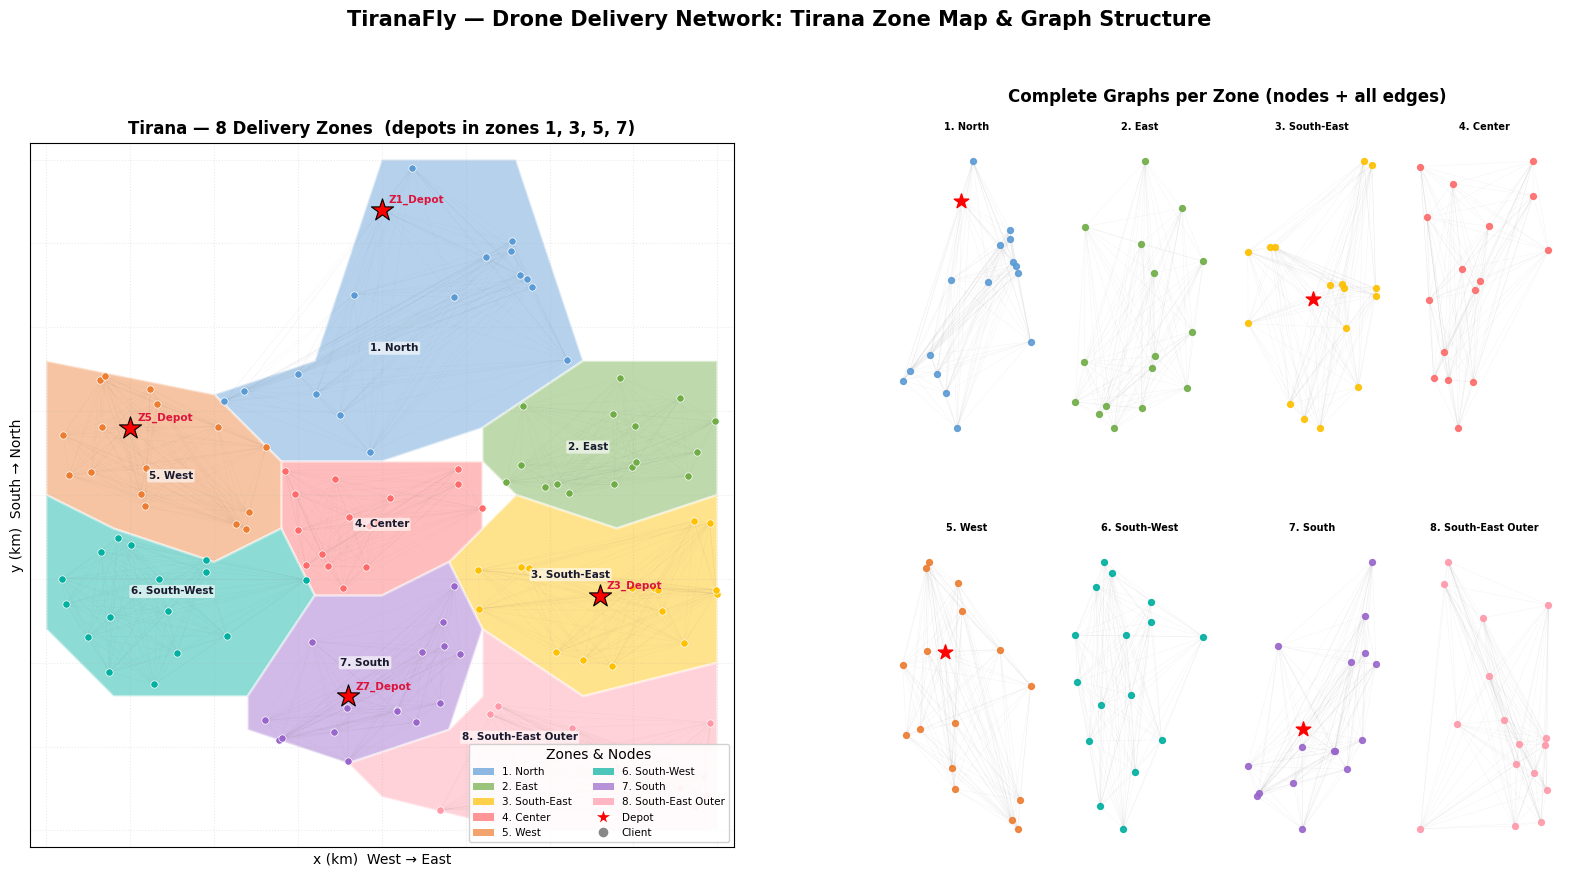

✅ Map saved → tirana_map.png


In [8]:
# ─── Visualisation: Tirana map + complete graphs ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("TiranaFly — Drone Delivery Network: Tirana Zone Map & Graph Structure",
             fontsize=15, fontweight='bold')

# ── Left panel: Zone polygons + nodes ─────────────────────────────────────────
ax = axes[0]
ax.set_title("Tirana — 8 Delivery Zones  (depots in zones 1, 3, 5, 7)", fontsize=12, fontweight='bold')

for zone_name, info in ZONES.items():
    poly_pts = np.array(info['poly'])
    patch = MplPolygon(poly_pts, closed=True,
                       facecolor=info['color'], edgecolor='white',
                       linewidth=1.8, alpha=0.45, zorder=1)
    ax.add_patch(patch)

    # Zone label (number + name)
    cx = np.mean(poly_pts[:,0])
    cy = np.mean(poly_pts[:,1])
    ax.text(cx, cy, f"{info['id']}. {zone_name}", ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='#1a1a2e', zorder=4,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.6, edgecolor='none'))

# Plot edges (per zone, very faint)
for zone_name, G in zone_graphs.items():
    pos = {n: (d['x'], d['y']) for n, d in G.nodes(data=True)}
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.04, width=0.4, edge_color='#555555')

# Plot clients
for zone_name, info in ZONES.items():
    color = info['color']
    for node in zone_nodes[zone_name]:
        if node['type'] == 'client':
            ax.scatter(node['x'], node['y'], c=color, s=28, zorder=3,
                       edgecolors='white', linewidths=0.5)

# Plot depots (on top)
for zone_name, info in ZONES.items():
    if info['depot']:
        for node in zone_nodes[zone_name]:
            if node['type'] == 'depot':
                ax.scatter(node['x'], node['y'], c='red', s=280,
                           marker='*', zorder=6, edgecolors='black', linewidths=0.8)
                ax.annotate(node['id'], (node['x'], node['y']),
                            textcoords='offset points', xytext=(5, 5),
                            fontsize=7.5, fontweight='bold', color='crimson', zorder=7)

ax.set_xlim(-0.5, 20.5); ax.set_ylim(-0.5, 20.5)
ax.set_xlabel("x (km)  West → East"); ax.set_ylabel("y (km)  South → North")
ax.grid(True, alpha=0.25, linestyle=':')
ax.set_aspect('equal')

# Legend
legend_handles = (
    [mpatches.Patch(facecolor=info['color'], label=f"{info['id']}. {z}", alpha=0.7)
     for z, info in ZONES.items()] +
    [plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='red', markersize=13, label='Depot'),
     plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888', markersize=8, label='Client')]
)
ax.legend(handles=legend_handles, loc='lower right', fontsize=7.5, ncol=2,
          framealpha=0.9, title="Zones & Nodes")

# ── Right panel: 8 mini-graphs (2×4 grid inset) ───────────────────────────────
ax2 = axes[1]
ax2.set_title("Complete Graphs per Zone (nodes + all edges)", fontsize=12, fontweight='bold')
ax2.axis('off')

# Draw 8 small sub-axes inside the right panel
zone_list = list(ZONES.keys())
rows, cols = 2, 4
for idx, zone_name in enumerate(zone_list):
    r, c = divmod(idx, cols)
    left  = 0.02 + c * 0.245
    bottom = 0.55 - r * 0.52
    sub_ax = fig.add_axes([axes[1].get_position().x0 + left * axes[1].get_position().width,
                           axes[1].get_position().y0 + bottom * axes[1].get_position().height,
                           0.22 * axes[1].get_position().width,
                           0.42 * axes[1].get_position().height])

    G = zone_graphs[zone_name]
    info = ZONES[zone_name]
    pos = {n: (d['x'], d['y']) for n, d in G.nodes(data=True)}
    depots  = [n for n,d in G.nodes(data=True) if d['type']=='depot']
    clients = [n for n,d in G.nodes(data=True) if d['type']=='client']

    nx.draw_networkx_edges(G, pos, ax=sub_ax, alpha=0.08, width=0.4, edge_color='grey')
    nx.draw_networkx_nodes(G, pos, nodelist=clients, ax=sub_ax,
                           node_color=info['color'], node_size=18, alpha=0.9)
    if depots:
        nx.draw_networkx_nodes(G, pos, nodelist=depots, ax=sub_ax,
                               node_color='red', node_size=120, node_shape='*', alpha=1.0)
    sub_ax.set_title(f"{info['id']}. {zone_name}", fontsize=7, fontweight='bold', pad=2)
    sub_ax.axis('off')

plt.savefig("tirana_map.png", dpi=160, bbox_inches='tight')
plt.show()
print("✅ Map saved → tirana_map.png")


---
## Step 8 — Edge Weight Statistics

In [10]:
# ─── Edge weight statistics per zone ─────────────────────────────────────────
print(f"{'Zone':<14} {'Nodes':>6} {'Edges':>7} {'Min km':>8} {'Max km':>8} "
      f"{'Mean km':>9} {'≤D_MAX':>8} {'Feasible%':>10}")
print("-"*80)

for z, G in zone_graphs.items():
    weights   = [d['weight'] for _,_,d in G.edges(data=True)]
    feasible  = sum(1 for w in weights if w <= D_MAX)
    pct       = feasible / len(weights) * 100 if weights else 0
    print(f"{z:<14} {G.number_of_nodes():>6} {len(weights):>7} "
          f"{min(weights):>8.2f} {max(weights):>8.2f} "
          f"{np.mean(weights):>9.2f} {feasible:>8} {pct:>9.1f}%")

print(f"\nDrone D_MAX = {D_MAX} km  |  MAX_PAYLOAD = {MAX_PAYLOAD} kg")


Zone            Nodes   Edges   Min km   Max km   Mean km   ≤D_MAX  Feasible%
--------------------------------------------------------------------------------
North              17     136     0.24    10.31      5.01      136     100.0%
East               16     120     0.21     6.48      2.89      120     100.0%
South-East         17     136     0.12     7.34      3.41      136     100.0%
Center             16     120     0.26     5.96      2.67      120     100.0%
West               17     136     0.18     6.20      3.13      136     100.0%
South-West         16     120     0.34     7.29      3.03      120     100.0%
South              17     136     0.02     6.95      3.05      136     100.0%
South-East Outer     16     120     0.09     8.46      3.41      120     100.0%

Drone D_MAX = 15.0 km  |  MAX_PAYLOAD = 4.0 kg


---
## Step 9 — Export Node & Edge Tables

CSV exports allow the routing and fleet modules to load data without re-running this notebook.

In [11]:
# ─── Export nodes ─────────────────────────────────────────────────────────────
df_nodes.to_csv("tirana_nodes.csv", index=False)
print("✅ tirana_nodes.csv saved")
print(df_nodes.head(6).to_string(index=False))

# ─── Export edges ─────────────────────────────────────────────────────────────
records = []
for z, G in zone_graphs.items():
    for u, v, d in G.edges(data=True):
        records.append({'zone': z, 'from': u, 'to': v,
                        'weight_km': d['weight'], 'feasible': d['feasible']})
df_edges = pd.DataFrame(records)
df_edges.to_csv("tirana_edges.csv", index=False)
print(f"\n✅ tirana_edges.csv saved  ({len(df_edges)} edges)")
print(df_edges.head(6).to_string(index=False))


✅ tirana_nodes.csv saved
      id       x       y   type  zone
Z1_Depot 10.0000 18.5000  depot North
   Z1_C1  8.0253 13.0089 client North
   Z1_C2 13.1012 17.0903 client North
   Z1_C3  9.6411 11.2682 client North
   Z1_C4  5.2919 12.7895 client North
   Z1_C5 12.1487 15.9045 client North

✅ tirana_edges.csv saved  (1024 edges)
 zone     from    to  weight_km  feasible
North Z1_Depot Z1_C1   5.835377      True
North Z1_Depot Z1_C2   3.406567      True
North Z1_Depot Z1_C3   7.240700      True
North Z1_Depot Z1_C4   7.401082      True
North Z1_Depot Z1_C5   3.369500      True
North Z1_Depot Z1_C6   4.051031      True


---
## Step 10 — Deliverables Summary

In [12]:
# ─── Summary of everything this module produces ──────────────────────────────
print("=" * 65)
print("  TiranaFly — Geospatial Module: Deliverables")
print("=" * 65)

print("\n📁 Exported files:")
for f in ["tirana_nodes.csv", "tirana_edges.csv", "tirana_map.png"]:
    print(f"   • {f}")

print("\n🗺  Grid  :  x,y ∈ [0, 20] km  |  centre = (10, 10)")
print("\n🏙  Zones :")
for z, info in ZONES.items():
    dep = " ★ DEPOT" if info['depot'] else ""
    print(f"   {info['id']}. {z:<14}  {info['area_pct']}%  {dep}")

print("\n🚁 Drone constants (shared with all modules):")
print(f"   D_MAX       = {D_MAX} km")
print(f"   MAX_PAYLOAD = {MAX_PAYLOAD} kg")

print("\n🐍 Python objects available for the routing module:")
print("   zone_nodes[zone_name]     – list of node dicts")
print("   zone_graphs[zone_name]    – networkx.Graph (weight, feasible on edges)")
print("   zone_adj_lists[zone_name] – adjacency list dict")
print("   df_nodes / df_edges       – pandas DataFrames")

print("=" * 65)


  TiranaFly — Geospatial Module: Deliverables

📁 Exported files:
   • tirana_nodes.csv
   • tirana_edges.csv
   • tirana_map.png

🗺  Grid  :  x,y ∈ [0, 20] km  |  centre = (10, 10)

🏙  Zones :
   1. North           17.2%   ★ DEPOT
   2. East            16.8%  
   3. South-East      14.3%   ★ DEPOT
   4. Center          15.5%  
   5. West            13.1%   ★ DEPOT
   6. South-West      11.8%  
   7. South           10.6%   ★ DEPOT
   8. South-East Outer  10.7%  

🚁 Drone constants (shared with all modules):
   D_MAX       = 15.0 km
   MAX_PAYLOAD = 4.0 kg

🐍 Python objects available for the routing module:
   zone_nodes[zone_name]     – list of node dicts
   zone_graphs[zone_name]    – networkx.Graph (weight, feasible on edges)
   zone_adj_lists[zone_name] – adjacency list dict
   df_nodes / df_edges       – pandas DataFrames


---
## Step 11 — Dijkstra / Shortest-Path Routing

This section adds the routing logic for the TiranaFly drone simulation.
The goal is not only to draw clients on the map, but also to decide **which path each drone should follow**.

In this project, every zone is treated as a **weighted graph**:

| Graph concept | Meaning in the project |
|---|---|
| Node | warehouse or client location |
| Edge | possible drone movement between two points |
| Weight | distance in kilometres |
| Path | sequence of nodes visited by a drone |

Because all distances are positive, **Dijkstra's algorithm is suitable** for shortest-path routing.
It chooses the next node with the smallest known distance and updates better paths until the shortest route is found.


### Routing problem in this notebook

For one selected zone, the program generates **16 clients** inside the zone.
Then the 4 drones must deliver to all clients while respecting these constraints:

| Constraint | Value | Meaning |
|---|---:|---|
| Number of clients | 16 | every client must be visited |
| Number of drones | 4 | several drones can share the work |
| Maximum load | 4 kg | one drone cannot carry more than 4 kg |
| Maximum route length | 15 km | depot → clients → depot must be at most 15 km |
| Assignment type | flexible | one drone may visit 1 client, another may visit 5, etc. |

The important part is that the clients are **not divided equally**.  
They are divided according to capacity and route distance.


### Why this is better than nearest neighbour

A simple **nearest-neighbour** method always chooses the closest next client.
This is easy, but it can give a poor total route because it makes a local decision at each step.

This notebook improves that idea:

1. It assigns clients to drones while checking the **4 kg** and **15 km** limits.
2. For each drone group, it computes the **shortest possible visiting order**.
3. The route always starts at the warehouse and returns to the warehouse.
4. Clients are coloured only when the drone actually reaches them in the animation.

So the route is not chosen randomly and not only by the next nearest client.
The objective is to keep the total distance as short as possible while satisfying the constraints.


### Algorithm logic

The routing part follows this logic:

```text
For the selected zone:
    1. Generate 16 client points inside the zone.
    2. Give each client a package weight.
    3. Start with 4 empty drone routes.
    4. Assign clients to drones:
          - total load of a drone must be ≤ 4 kg
          - total route of a drone must be ≤ 15 km
          - choose the option that adds the smallest extra distance
    5. For each drone, compute the shortest visiting order.
    6. Animate each drone:
          warehouse → assigned clients → warehouse
    7. When all drones return, the user can click another zone.
```

The shortest-path idea is used through the distance matrix between warehouse and clients.
The final visiting order is computed exactly for the selected group of clients, instead of using a greedy nearest-neighbour shortcut.


### Complexity interpretation

Let:

- **V** = number of nodes in the selected zone
- **E** = number of possible edges
- **k** = number of clients assigned to one drone

For Dijkstra on a weighted graph, the usual complexity with a priority queue is:

$$O((V + E) \log V)$$

In this final simulation, each drone has only a small number of assigned clients, so the exact shortest visiting order is still practical.
This is why the animation can run live after clicking a zone.

### What to say during presentation

> In this part, I model the delivery area as a weighted graph. The nodes are the warehouse and clients, and the edge weights are distances. Since all distances are positive, Dijkstra's shortest-path idea is appropriate. The program assigns all 16 clients to drones while checking the 4 kg payload limit and the 15 km total route limit. Then each drone follows the shortest route for its assigned clients and returns to the warehouse. This is better than nearest neighbour because it does not only choose the closest next client; it checks the full route and constraints.


---
## Step 12 — Final Interactive Drone Simulation

Run the code cell below to open the interactive TiranaFly simulation.
After the map appears:

1. Click one zone.
2. Watch the drones deliver to all 16 clients.
3. Wait until all drones return to the warehouse.
4. Click another zone to run the next simulation.

The final version keeps the requirements from the project:

- all 16 clients are visited,
- clients are coloured only when visited,
- client assignment is flexible,
- each drone has maximum **4 kg** load,
- each drone has maximum **15 km** total route,
- the route is based on shortest-path logic, not nearest-neighbour.


In [13]:
"""
Tirana Drone Delivery Simulation v4
=====================================
- 8 real Tirana zones with accurate coordinates
- Industrial warehouse (grey + yellow, matching photo)
- Customers get colored ONLY when drone visits them
- Dijkstra/shortest-path routing idea: use weighted distances, not nearest-neighbour guessing
- Exact shortest route per drone for its assigned clients; all 16 customers are visited
- Each drone stays under 4 kg total load and 15 km total route; clients are assigned flexibly, not 4 each
- Click map to select zone → live animation in same window (no GIF)
- After one zone finishes, click another zone; click detection uses polygon hit-testing
"""

import numpy as np
import matplotlib
# Mac fix: use native MacOSX backend first. If it is unavailable, use TkAgg.
# Agg is only a safe fallback for environments without a display.
try:
    matplotlib.use('MacOSX')
except Exception:
    try:
        matplotlib.use('TkAgg')
    except Exception:
        matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, FancyBboxPatch, Polygon as MplPoly
from matplotlib.animation import FuncAnimation
from matplotlib.colors import to_rgba
import matplotlib.gridspec as gridspec
import math, random

random.seed(42)
np.random.seed(42)

# ═══════════════════════════════════════════════════════════════
# ZONES — untouched coordinates
# ═══════════════════════════════════════════════════════════════
ZONES = {
    "Z1 - KAMZA": {
        "color": "#AED6F1", "border": "#2E86C1",
        "coords": [(-3.5,8.5),(-2.0,9.8),(0.2,10.2),(1.8,9.5),(2.5,8.0),
                   (1.5,6.5),(0.0,6.0),(-1.5,6.2),(-3.0,7.0),(-3.5,8.5)]
    },
    "Z2 - PASKUQANI": {
        "color": "#A9DFBF", "border": "#1E8449",
        "coords": [(1.8,9.5),(3.5,10.0),(5.5,9.2),(6.5,7.8),(5.8,6.5),
                   (4.2,6.0),(2.5,6.5),(1.5,6.5),(2.5,8.0),(1.8,9.5)]
    },
    "Z3 - ALI DEMI": {
        "color": "#FAD7A0", "border": "#D4AC0D",
        "coords": [(4.2,6.0),(5.8,6.5),(6.5,7.8),(7.5,6.0),(7.2,4.0),
                   (6.0,2.5),(4.5,2.0),(3.2,3.0),(3.0,4.5),(4.2,6.0)]
    },
    "Z4 - QENDRA": {
        "color": "#F1948A", "border": "#C0392B",
        "coords": [(-1.5,6.2),(0.0,6.0),(1.5,6.5),(2.5,6.5),(4.2,6.0),
                   (3.0,4.5),(3.2,3.0),(1.5,2.0),(0.0,1.5),(-1.5,2.0),
                   (-2.5,3.5),(-2.8,5.0),(-1.5,6.2)]
    },
    "Z5 - KASHARI": {
        "color": "#F0B27A", "border": "#CA6F1E",
        "coords": [(-7.0,7.5),(-5.5,8.5),(-3.5,8.5),(-3.0,7.0),(-1.5,6.2),
                   (-2.8,5.0),(-4.5,4.5),(-6.0,5.5),(-7.0,7.5)]
    },
    "Z6 - LAPRAKA": {
        "color": "#A2D9CE", "border": "#0E6655",
        "coords": [(-6.0,5.5),(-4.5,4.5),(-2.8,5.0),(-2.5,3.5),(-1.5,2.0),
                   (-2.0,0.5),(-3.5,-0.5),(-5.5,0.5),(-6.5,2.5),(-6.0,5.5)]
    },
    "Z7 - KOMUNA E PARISIT": {
        "color": "#D7BDE2", "border": "#6C3483",
        "coords": [(-1.5,2.0),(0.0,1.5),(1.5,2.0),(3.2,3.0),(4.5,2.0),
                   (3.5,0.0),(2.0,-1.5),(0.0,-2.5),(-2.0,-1.5),(-2.0,0.5),(-1.5,2.0)]
    },
    "Z8 - FARKA": {
        "color": "#FADBD8", "border": "#C0392B",
        "coords": [(3.2,3.0),(4.5,2.0),(6.0,2.5),(7.2,4.0),(7.5,2.0),
                   (6.5,0.5),(5.0,-0.5),(3.5,0.0),(4.5,2.0),(3.2,3.0)]
    }
}

WAREHOUSES = {
    "WH-A": {"zones": ["Z1 - KAMZA","Z2 - PASKUQANI"],        "color": "#1565C0", "pos": (1.0, 11.2)},
    "WH-B": {"zones": ["Z3 - ALI DEMI","Z8 - FARKA"],          "color": "#B71C1C", "pos": (8.5,  4.0)},
    "WH-C": {"zones": ["Z5 - KASHARI","Z6 - LAPRAKA"],         "color": "#1B5E20", "pos": (-8.5, 5.0)},
    "WH-D": {"zones": ["Z4 - QENDRA","Z7 - KOMUNA E PARISIT"],"color": "#4A148C", "pos": (0.0, -4.5)},
}
ZONE_TO_WH = {z: wh for wh, info in WAREHOUSES.items() for z in info["zones"]}

DRONE_COLORS = ["#FF3333", "#00BBFF", "#FFD700", "#33FF88"]
N_DRONES    = 4
N_CUSTOMERS = 16
MAX_KM      = 15.0   # maximum total route distance per drone: depot -> clients -> depot
MAX_KG      = 4.0    # maximum total package weight per drone
KM_PER_MAP_UNIT = 0.55  # converts drawing/map units into route kilometers

# ═══════════════════════════════════════════════════════════════
# GEOMETRY
# ═══════════════════════════════════════════════════════════════
def smooth_polygon(pts, n=120):
    pts = np.array(pts)
    try:
        from scipy.interpolate import splprep, splev
        pts_closed = np.vstack([pts, pts[0]])
        x, y = pts_closed[:, 0], pts_closed[:, 1]
        tck, u = splprep([x, y], s=0.5, per=True, k=3)
        xn, yn = splev(np.linspace(0, 1, n), tck)
        return np.column_stack([xn, yn])
    except Exception:
        # If scipy is not installed, the map still works using the original polygons.
        return pts

def ray_cast(px, py, poly):
    inside = False; j = len(poly)-1
    for i in range(len(poly)):
        xi,yi = poly[i]; xj,yj = poly[j]
        if ((yi>py)!=(yj>py)) and px < (xj-xi)*(py-yi)/(yj-yi+1e-12)+xi:
            inside = not inside
        j = i
    return inside

def poly_centroid(poly):
    poly = np.array(poly)
    return poly[:,0].mean(), poly[:,1].mean()

def sample_customers(smooth_poly, n=16):
    pts = np.array(smooth_poly)
    xmin,xmax = pts[:,0].min(), pts[:,0].max()
    ymin,ymax = pts[:,1].min(), pts[:,1].max()
    result = []; attempts = 0
    while len(result) < n and attempts < 20000:
        px,py = random.uniform(xmin,xmax), random.uniform(ymin,ymax)
        if ray_cast(px,py,pts) and all(math.dist((px,py),p)>0.22 for p in result):
            result.append((px,py))
        attempts += 1
    return result[:n]

# ═══════════════════════════════════════════════════════════════
# ROUTING — shortest route, strict 15 km
# ═══════════════════════════════════════════════════════════════
def route_length(wh_pos, customers, order):
    """Total km for warehouse -> ordered customers -> warehouse."""
    pts = [wh_pos] + [customers[i] for i in order] + [wh_pos]
    return sum(math.dist(pts[i], pts[i+1]) * KM_PER_MAP_UNIT for i in range(len(pts)-1))

def shortest_delivery_route(wh_pos, customers, cids):
    """
    Exact shortest route for one drone.
    This replaces nearest-neighbour: it checks all route states with dynamic programming
    and returns the minimum tour warehouse -> customers -> warehouse.
    """
    cids = list(cids)
    n = len(cids)
    if n == 0:
        return [wh_pos, wh_pos], [], 0.0

    # distances: node 0 is warehouse, nodes 1..n are selected customers
    nodes = [wh_pos] + [customers[i] for i in cids]
    dist = [[math.dist(nodes[i], nodes[j]) * KM_PER_MAP_UNIT for j in range(n+1)] for i in range(n+1)]

    # DP[(mask, last)] = (cost, previous_last)
    # mask stores visited customers using bits 0..n-1, last is customer index 0..n-1
    dp = {}
    for j in range(n):
        dp[(1 << j, j)] = (dist[0][j+1], None)

    for mask in range(1 << n):
        for last in range(n):
            if (mask, last) not in dp:
                continue
            cur_cost, _ = dp[(mask, last)]
            for nxt in range(n):
                if mask & (1 << nxt):
                    continue
                new_mask = mask | (1 << nxt)
                new_cost = cur_cost + dist[last+1][nxt+1]
                key = (new_mask, nxt)
                if key not in dp or new_cost < dp[key][0]:
                    dp[key] = (new_cost, last)

    full = (1 << n) - 1
    best_last = min(range(n), key=lambda j: dp[(full, j)][0] + dist[j+1][0])
    best_cost = dp[(full, best_last)][0] + dist[best_last+1][0]

    # reconstruct order
    order_local = []
    mask, last = full, best_last
    while last is not None:
        order_local.append(last)
        prev = dp[(mask, last)][1]
        mask ^= (1 << last)
        last = prev
    order_local.reverse()

    ordered_cids = [cids[j] for j in order_local]
    waypoints = [wh_pos] + [customers[i] for i in ordered_cids] + [wh_pos]
    return waypoints, ordered_cids, best_cost

def make_customer_weights(n):
    """Package weights in kg. They are not equal, so the drones do NOT get the same number of clients."""
    # Total load is below 4 drones × 4 kg, but single-drone loads must stay <= 4 kg.
    pattern = [0.6, 0.9, 0.7, 1.2, 0.8, 0.5, 1.1, 0.6,
               0.9, 0.7, 1.0, 0.8, 0.6, 1.2, 0.5, 0.9]
    return [pattern[i % len(pattern)] for i in range(n)]

def route_length_for_group(wh_pos, customers, cids):
    """Length of the exact shortest route for this group of clients."""
    _, _, dist = shortest_delivery_route(wh_pos, customers, cids)
    return dist

def plan_routes(wh_pos, customers, weights, max_kg=4.0, max_km=15.0):
    """
    Assign all 16 customers to drones with flexible grouping.

    Important: this does NOT force 4 clients per drone.
    A drone may visit 1 client, another may visit 5 clients, etc.,
    as long as the total package weight of each drone is <= 4 kg
    and the total route distance is <= 15 km.

    The assignment tries to minimize the total shortest-route distance.
    After assignment, each drone's visiting order is computed with exact shortest path DP.
    """
    groups = [[] for _ in range(N_DRONES)]
    loads = [0.0 for _ in range(N_DRONES)]

    # Start with farthest customers first, because they are harder to insert later.
    order = sorted(range(len(customers)), key=lambda i: math.dist(wh_pos, customers[i]), reverse=True)

    for idx in order:
        best_drone = None
        best_score = float('inf')

        for d in range(N_DRONES):
            if loads[d] + weights[idx] > max_kg + 1e-9:
                continue

            old_dist = route_length_for_group(wh_pos, customers, groups[d])
            new_dist = route_length_for_group(wh_pos, customers, groups[d] + [idx])
            if new_dist > max_km + 1e-9:
                continue
            added_distance = new_dist - old_dist

            # Main priority: shortest added distance.
            # Small tie-breaker: prefer the drone with lighter load, but do NOT force equal clients.
            score = added_distance + 0.03 * loads[d]
            if score < best_score:
                best_score = score
                best_drone = d

        if best_drone is None:
            raise ValueError(
                "Cannot assign all customers under 4 kg and 15 km per drone. Reduce package weights, move warehouse closer, or add more drones."
            )

        groups[best_drone].append(idx)
        loads[best_drone] += weights[idx]

    # Optional local improvement: move a client to another drone if total distance becomes shorter.
    improved = True
    while improved:
        improved = False
        current_total = sum(route_length_for_group(wh_pos, customers, g) for g in groups)

        for a in range(N_DRONES):
            for cid in list(groups[a]):
                for b in range(N_DRONES):
                    if a == b:
                        continue
                    if loads[b] + weights[cid] > max_kg + 1e-9:
                        continue

                    new_groups = [list(g) for g in groups]
                    new_groups[a].remove(cid)
                    new_groups[b].append(cid)
                    if any(route_length_for_group(wh_pos, customers, g) > max_km + 1e-9 for g in new_groups):
                        continue
                    new_total = sum(route_length_for_group(wh_pos, customers, g) for g in new_groups)

                    if new_total + 1e-9 < current_total:
                        groups = new_groups
                        loads[a] -= weights[cid]
                        loads[b] += weights[cid]
                        improved = True
                        break
                if improved:
                    break
            if improved:
                break

    routes = []
    for d_idx, cids in enumerate(groups):
        wp, ordered, dist = shortest_delivery_route(wh_pos, customers, cids)
        load = sum(weights[i] for i in ordered)
        routes.append({
            "path": wp,
            "cust_ids": ordered,
            "dist": dist,
            "load": load,
            "over_capacity": load > max_kg + 1e-9,
            "over_distance": dist > max_km + 1e-9
        })
    return routes

# ═══════════════════════════════════════════════════════════════
# PRE-COMPUTE smooth polygons at module load
# ═══════════════════════════════════════════════════════════════
SMOOTH_POLYS = {zname: smooth_polygon(zinfo["coords"], n=150)
                for zname, zinfo in ZONES.items()}

# ═══════════════════════════════════════════════════════════════
# WAREHOUSE DRAWING — industrial grey + yellow (matches photo)
# ═══════════════════════════════════════════════════════════════
def draw_warehouse_3d(ax, x, y, color, label, s=0.5, zorder=30):
    GREY="#3A3F47"; YELLOW="#FFD700"; DARK="#22262C"; WIN_BG="#1A2430"
    W=s*2.4; H=s*0.85; D=s*0.25
    # right depth
    ax.fill([x+W/2,x+W/2+D,x+W/2+D,x+W/2],[y-H/2,y-H/2+D,y+H/2+D,y+H/2], color=DARK, zorder=zorder)
    ax.plot([x+W/2,x+W/2+D,x+W/2+D,x+W/2,x+W/2],[y-H/2,y-H/2+D,y+H/2+D,y+H/2,y-H/2], color=YELLOW, lw=0.8, zorder=zorder+1)
    # top
    ax.fill([x-W/2,x+W/2,x+W/2+D,x-W/2+D],[y+H/2,y+H/2,y+H/2+D,y+H/2+D], color="#2A2E35", zorder=zorder+1)
    ax.plot([x-W/2,x+W/2,x+W/2+D,x-W/2+D,x-W/2],[y+H/2,y+H/2,y+H/2+D,y+H/2+D,y+H/2], color=YELLOW, lw=0.8, zorder=zorder+2)
    # body
    ax.add_patch(FancyBboxPatch((x-W/2,y-H/2),W,H,boxstyle="square,pad=0",fc=GREY,ec=YELLOW,lw=1.6,zorder=zorder+2))
    # corner pillars
    for cx_ in [x-W/2, x+W/2-s*0.13]:
        ax.add_patch(FancyBboxPatch((cx_,y-H/2),s*0.13,H,boxstyle="square,pad=0",fc=YELLOW,ec="none",zorder=zorder+3))
    # door
    dw,dh,dx_=s*0.30,H*0.72,x+W/2-s*0.50
    ax.add_patch(FancyBboxPatch((dx_,y-H/2),dw,dh,boxstyle="square,pad=0",fc=YELLOW,ec="none",zorder=zorder+3))
    ax.add_patch(FancyBboxPatch((dx_+s*0.04,y-H/2+s*0.04),dw-s*0.08,dh-s*0.04,boxstyle="square,pad=0",fc="#2A2E35",ec="none",zorder=zorder+4))
    # windows
    wy_=y+H*0.06; wx0=x-W/2+s*0.28
    for i in range(4):
        wx_=wx0+i*s*0.37
        if wx_+s*0.26 > dx_-s*0.04: break
        ax.add_patch(FancyBboxPatch((wx_-s*0.03,wy_-s*0.03),s*0.26+s*0.06,H*0.36+s*0.06,boxstyle="square,pad=0",fc=YELLOW,ec="none",zorder=zorder+3))
        ax.add_patch(FancyBboxPatch((wx_,wy_),s*0.26,H*0.36,boxstyle="square,pad=0",fc=WIN_BG,ec="none",zorder=zorder+4))
    ax.text(x, y-H/2-s*0.20, label, ha='center', va='top', fontsize=7.5, fontweight='bold',
            color='white', zorder=zorder+10,
            bbox=dict(boxstyle='round,pad=0.25',fc=GREY,ec=YELLOW,lw=1.2,alpha=0.95))

# ═══════════════════════════════════════════════════════════════
# BUILD LIVE ANIMATION  (runs inside an existing axes, no file save)
# ═══════════════════════════════════════════════════════════════
def build_live_animation(zone_name, ax_map, ax_sim, fig, canvas, on_done=None, zone_patches=None):
    """Set up and return FuncAnimation that draws live into ax_sim."""
    wh_key  = ZONE_TO_WH[zone_name]
    wh_info = WAREHOUSES[wh_key]
    wh_pos  = wh_info["pos"]
    zinfo   = ZONES[zone_name]
    sp      = SMOOTH_POLYS[zone_name]
    z_color = zinfo["color"]; z_border = zinfo["border"]

    customers = sample_customers(sp, N_CUSTOMERS)
    weights   = make_customer_weights(len(customers))
    routes    = plan_routes(wh_pos, customers, weights, MAX_KG, MAX_KM)

    # ── left map panel ──────────────────────────────────────────
    ax_map.clear()
    ax_map.set_facecolor("#1A1A2E")
    ax_map.set_aspect('equal'); ax_map.set_xlim(-9.5,9.5); ax_map.set_ylim(-5.5,12.5); ax_map.axis('off')
    if zone_patches is not None:
        zone_patches.clear()
    for zn,zi in ZONES.items():
        sp2=SMOOTH_POLYS[zn]; is_hi=(zn==zone_name)
        patch = MplPoly(sp2,closed=True,fc=to_rgba(zi["color"],0.80 if is_hi else 0.20),
                        ec=zi["border"],lw=2.2 if is_hi else 0.8,picker=True,zorder=2)
        ax_map.add_patch(patch)
        if zone_patches is not None:
            zone_patches[zn] = patch
        cx,cy=poly_centroid(sp2); parts=zn.split(" - ")
        ax_map.text(cx,cy+0.1,parts[0],ha='center',va='center',
                    fontsize=7.5 if is_hi else 6.0,fontweight='bold' if is_hi else 'normal',
                    color='white' if is_hi else '#88AACC',zorder=6,
                    path_effects=[pe.withStroke(linewidth=2,foreground='black')])
        if is_hi and len(parts)>1:
            ax_map.text(cx,cy-0.35,parts[1],ha='center',va='center',fontsize=6.5,color='#CCDDFF',zorder=6,
                        path_effects=[pe.withStroke(linewidth=1.5,foreground='black')])
    for wn,wi in WAREHOUSES.items():
        draw_warehouse_3d(ax_map,wi["pos"][0],wi["pos"][1],wi["color"],wn,s=0.42,zorder=30)
    scx,scy=poly_centroid(sp)
    ax_map.annotate('',xy=(scx,scy),xytext=(wh_pos[0],wh_pos[1]),
                    arrowprops=dict(arrowstyle='->',color='#FFD700',lw=2.0,mutation_scale=16,
                                    connectionstyle='arc3,rad=0.1'),zorder=40)
    ax_map.scatter([scx],[scy],marker='*',s=180,color='#FFD700',edgecolors='white',lw=0.8,zorder=41)
    leg_els=[mpatches.Patch(fc=DRONE_COLORS[d],ec='white',label=f"Drone {d+1}") for d in range(N_DRONES)]
    leg_els.append(mpatches.Patch(fc='#555',ec='#888',label='Not visited'))
    ax_map.legend(handles=leg_els,loc='lower left',fontsize=7,facecolor='#0D1117',
                  edgecolor='#334',labelcolor='white',framealpha=0.9)

    # ── right sim panel ─────────────────────────────────────────
    ax_sim.clear()
    xs=sp[:,0]; ys=sp[:,1]; wx_pos,wy_pos=wh_pos; pad=1.2
    x0=min(xs.min(),wx_pos)-pad; x1=max(xs.max(),wx_pos)+pad
    y0=min(ys.min(),wy_pos)-pad; y1=max(ys.max(),wy_pos)+pad
    ax_sim.set_facecolor('#0D1117'); ax_sim.set_xlim(x0,x1); ax_sim.set_ylim(y0,y1)
    ax_sim.set_aspect('equal'); ax_sim.axis('off')
    for gx in np.arange(math.floor(x0),math.ceil(x1)+1,0.5):
        ax_sim.axvline(gx,color='#1A2440',lw=0.4,zorder=0)
    for gy in np.arange(math.floor(y0),math.ceil(y1)+1,0.5):
        ax_sim.axhline(gy,color='#1A2440',lw=0.4,zorder=0)
    ax_sim.add_patch(MplPoly(sp+np.array([0.05,-0.05]),closed=True,fc='#00000040',ec='none',zorder=1))
    ax_sim.add_patch(MplPoly(sp,closed=True,fc=to_rgba(z_color,0.15),ec=z_border,lw=2.5,zorder=2))
    ax_sim.text((x0+x1)/2,y1-0.15,zone_name,ha='center',va='top',fontsize=13,fontweight='bold',
                color=z_border,zorder=6,path_effects=[pe.withStroke(linewidth=3,foreground='black')])
    ax_sim.add_patch(Circle((wx_pos,wy_pos),MAX_KM*0.4,fc='none',ec='#FFFFFF15',lw=1.2,ls='--',zorder=3))
    draw_warehouse_3d(ax_sim,wx_pos,wy_pos,wh_info["color"],wh_key,s=0.50,zorder=35)

    # customers: grey at first; colored only when visited
    cust_arts=[]
    for i, (cx_, cy_) in enumerate(customers):
        c = Circle((cx_, cy_), 0.11, fc='#555555', ec='#888888', lw=0.8, zorder=10)
        ax_sim.add_patch(c)
        cust_arts.append(c)
        ax_sim.text(cx_, cy_ + 0.18, f"{weights[i]:.1f}kg", ha='center', va='bottom',
                    fontsize=6.2, color='#CCCCCC', zorder=11,
                    path_effects=[pe.withStroke(linewidth=1.4, foreground='black')])

    # visit schedule
    STEPS=20; HOLD=15; END_HOLD=25
    visit_schedule={}
    for d_idx,route in enumerate(routes):
        for seg,cid in enumerate(route['cust_ids']):
            visit_schedule[cid]=(d_idx, HOLD+(seg+1)*STEPS)

    max_segs=max(len(r['path'])-1 for r in routes)
    TOTAL=HOLD+max_segs*STEPS+END_HOLD

    # trails
    trail_arts=[]
    for d_idx,route in enumerate(routes):
        dc=DRONE_COLORS[d_idx]
        for si in range(len(route['path'])-1):
            ln,=ax_sim.plot([],[],color=dc,lw=2.0,alpha=0.75,ls='--',zorder=8,solid_capstyle='round')
            trail_arts.append((d_idx,si,ln,route['path'][si],route['path'][si+1]))

    # drone parts
    D=0.19
    d_arms=[[ax_sim.plot([],[],color=DRONE_COLORS[d],lw=2.5,solid_capstyle='round',zorder=50)[0]
             for _ in range(4)] for d in range(N_DRONES)]
    d_rotor_o=[[Circle((0,0),D*0.33,fc=to_rgba(DRONE_COLORS[d],0.35),ec=DRONE_COLORS[d],lw=1.8,zorder=51,visible=False)
                for _ in range(4)] for d in range(N_DRONES)]
    d_rotor_i=[[Circle((0,0),D*0.18,fc=DRONE_COLORS[d],ec='white',lw=1.0,zorder=52,visible=False)
                for _ in range(4)] for d in range(N_DRONES)]
    d_body=[Circle((0,0),D*0.42,fc=DRONE_COLORS[d],ec='white',lw=2.0,zorder=53,visible=False) for d in range(N_DRONES)]
    d_cam =[Circle((0,0),D*0.16,fc='#111',ec='white',lw=0.8,zorder=54,visible=False) for d in range(N_DRONES)]
    d_led =[Circle((0,0),D*0.09,fc='white',ec='none',zorder=55,visible=False) for d in range(N_DRONES)]
    for d in range(N_DRONES):
        for k in range(4): ax_sim.add_patch(d_rotor_o[d][k]); ax_sim.add_patch(d_rotor_i[d][k])
        ax_sim.add_patch(d_body[d]); ax_sim.add_patch(d_cam[d]); ax_sim.add_patch(d_led[d])

    status=ax_sim.text(x0+0.1,y0+0.15,'',ha='left',va='bottom',fontsize=8.5,color='#AABBCC',fontfamily='monospace',zorder=60)
    dtxts=[ax_sim.text(x0+0.1,y1-0.20-d*0.35,'',ha='left',va='top',fontsize=8,color=DRONE_COLORS[d],fontfamily='monospace',zorder=60)
           for d in range(N_DRONES)]
    ax_sim.text((x0+x1)/2,y0+0.15,f'Capacity: {MAX_KG:.0f} kg per drone | Flexible clients per drone | All {N_CUSTOMERS} customers visited',ha='center',va='bottom',fontsize=7.5,color='#667788',fontfamily='monospace',zorder=60)

    drone_done=[False]*N_DRONES; live_dist=[0.0]*N_DRONES
    visited_set=set()

    def show_drone(d,x,y):
        dirs=[(-1,0),(1,0),(0,-1),(0,1)]
        for k,(dx,dy) in enumerate(dirs):
            d_arms[d][k].set_data([x,x+dx*D],[y,y+dy*D])
            d_rotor_o[d][k].center=(x+dx*D,y+dy*D); d_rotor_o[d][k].set_visible(True)
            d_rotor_i[d][k].center=(x+dx*D,y+dy*D); d_rotor_i[d][k].set_visible(True)
        d_body[d].center=(x,y); d_body[d].set_visible(True)
        d_cam[d].center=(x,y);  d_cam[d].set_visible(True)
        d_led[d].center=(x+D*0.18,y+D*0.18); d_led[d].set_visible(True)

    def hide_drone(d):
        for k in range(4):
            d_arms[d][k].set_data([],[])
            d_rotor_o[d][k].set_visible(False); d_rotor_i[d][k].set_visible(False)
        d_body[d].set_visible(False); d_cam[d].set_visible(False); d_led[d].set_visible(False)

    def update(frame):
        for cid,(d_idx,arr) in visit_schedule.items():
            if frame>=arr:
                cust_arts[cid].set_facecolor(DRONE_COLORS[d_idx])
                cust_arts[cid].set_edgecolor('white')
                visited_set.add(cid)
        if frame<HOLD:
            status.set_text("System ready... flexible client assignment, max 4kg per drone ►")
            return
        ff=frame-HOLD
        for d_idx,route in enumerate(routes):
            pts=route['path']; nseg=len(pts)-1
            cur=ff//STEPS; prog=(ff%STEPS)/STEPS; t=prog*prog*(3-2*prog)
            if cur>=nseg:
                drone_done[d_idx]=True; hide_drone(d_idx); live_dist[d_idx]=route['dist']
            else:
                x0r,y0r=pts[cur]; x1r,y1r=pts[cur+1]
                xd=x0r+(x1r-x0r)*t; yd=y0r+(y1r-y0r)*t
                show_drone(d_idx,xd,yd)
                pd=sum(math.dist(pts[s],pts[s+1]) * KM_PER_MAP_UNIT for s in range(cur))
                pd+=math.dist(pts[cur],(xd,yd)) * KM_PER_MAP_UNIT; live_dist[d_idx]=pd
                for art in trail_arts:
                    adi,si,ln,p0,p1=art
                    if adi==d_idx:
                        if si<cur: ln.set_data([p0[0],p1[0]],[p0[1],p1[1]])
                        elif si==cur: ln.set_data([x0r,xd],[y0r,yd])
            icon="✓" if drone_done[d_idx] else "►"
            dtxts[d_idx].set_text(f"Drone {d_idx+1}: {live_dist[d_idx]:.2f}km | {route['load']:.1f}/{MAX_KG:.0f}kg | {len(route['cust_ids'])} clients {icon}")
        if all(drone_done):
            status.set_text(f"✓ All deliveries done! Visited {len(visited_set)}/{N_CUSTOMERS}. Drones returned.")
            if on_done: on_done()
        else:
            status.set_text(f"► {sum(1 for d in drone_done if not d)} drone(s) flying... visited {len(visited_set)}/{N_CUSTOMERS}")

    anim = FuncAnimation(fig, update, frames=TOTAL, interval=30, blit=False, repeat=False)
    canvas.draw()
    return anim   # caller must keep reference

# ═══════════════════════════════════════════════════════════════
# MAIN WINDOW — interactive map → click zone → live sim
# ═══════════════════════════════════════════════════════════════
def launch_gui():
    """
    Mac-stable version: uses the normal Matplotlib window instead of embedding
    Matplotlib inside a Tkinter canvas. This avoids the blank white Tkinter page.
    """
    selected_zone = [None]
    zone_patches = {}
    anim_ref = [None]  # keep FuncAnimation alive
    status_text = [None]

    fig = plt.figure(figsize=(16, 8.5), facecolor='#1A1A2E', dpi=90)
    try:
        fig.canvas.manager.set_window_title("Tirana Drone Delivery")
    except Exception:
        pass

    fig.text(0.5, 0.97, "TIRANA DRONE DELIVERY SIMULATION",
             ha='center', fontsize=13, fontweight='bold', color='#00D4FF', fontfamily='monospace',
             path_effects=[pe.withStroke(linewidth=3, foreground='#000033')])
    fig.text(0.5, 0.935, "Click a zone on the left map to start. After it finishes, click another zone.",
             ha='center', fontsize=9, color='#8899BB', fontfamily='monospace')

    gs = gridspec.GridSpec(1, 2, width_ratios=[0.9, 1.5],
                           left=0.01, right=0.99, bottom=0.04, top=0.90, wspace=0.03)
    ax_map = fig.add_subplot(gs[0])
    ax_sim = fig.add_subplot(gs[1])

    def draw_selector_map():
        ax_map.clear()
        ax_map.set_facecolor("#1A1A2E")
        ax_map.set_aspect('equal')
        ax_map.set_xlim(-9.5, 9.5)
        ax_map.set_ylim(-5.5, 12.5)
        ax_map.axis('off')
        zone_patches.clear()

        for zname, zinfo in ZONES.items():
            sp = SMOOTH_POLYS[zname]
            is_selected = (zname == selected_zone[0])
            patch = MplPoly(
                sp, closed=True,
                fc=to_rgba(zinfo["color"], 0.95 if is_selected else 0.65),
                ec=zinfo["border"],
                lw=4.0 if is_selected else 1.8,
                picker=True,
                zorder=2
            )
            ax_map.add_patch(patch)
            zone_patches[zname] = patch

            cx, cy = poly_centroid(sp)
            parts = zname.split(" - ")
            ax_map.text(cx, cy + 0.15, parts[0], ha='center', va='center',
                        fontsize=7.5, fontweight='bold', color='white', zorder=5,
                        path_effects=[pe.withStroke(linewidth=2, foreground='black')])
            if len(parts) > 1:
                ax_map.text(cx, cy - 0.35, parts[1], ha='center', va='center',
                            fontsize=6, color='#CCDDFF', zorder=5,
                            path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])

        for wn, wi in WAREHOUSES.items():
            draw_warehouse_3d(ax_map, wi["pos"][0], wi["pos"][1], wi["color"], wn, s=0.42, zorder=30)

    draw_selector_map()

    ax_sim.set_facecolor('#0D1117')
    ax_sim.axis('off')
    ax_sim.text(0.5, 0.5, "← Click a zone to start", ha='center', va='center',
                fontsize=14, color='#334466', transform=ax_sim.transAxes, fontfamily='monospace')

    status_text[0] = fig.text(0.015, 0.012, "No zone selected — click the map",
                              ha='left', va='bottom', fontsize=9, fontweight='bold',
                              color='#FFD700', fontfamily='monospace')

    def set_status(msg):
        if status_text[0] is not None:
            status_text[0].set_text(msg)
            fig.canvas.draw_idle()

    def on_click(event):
        """Select zones using normal mouse clicks, not Matplotlib picker.
        This is more reliable on Mac after the axes are cleared/redrawn by animation.
        """
        if event.inaxes is not ax_map or event.xdata is None or event.ydata is None:
            return

        chosen = None
        # Check if the clicked point is inside any zone polygon.
        # Use reversed order so the top-most visible polygon wins if borders overlap.
        for zname in reversed(list(ZONES.keys())):
            if ray_cast(event.xdata, event.ydata, SMOOTH_POLYS[zname]):
                chosen = zname
                break

        if chosen is None:
            return

        selected_zone[0] = chosen
        set_status(f"Selected: {chosen} — launching simulation...")

        # Stop the previous animation completely before starting a new one.
        if anim_ref[0] is not None:
            try:
                anim_ref[0].event_source.stop()
            except Exception:
                pass
        anim_ref[0] = None

        # Keep only the main title, instruction line and bottom status.
        fig.texts = [
            t for t in fig.texts
            if t is status_text[0]
            or "TIRANA DRONE" in t.get_text()
            or "Click a zone" in t.get_text()
        ]
        fig.text(0.5, 0.910,
                 f"Zone: {chosen}  ►  Warehouse: {ZONE_TO_WH[chosen]}  ►  Shortest Path  ►  Capacity: {MAX_KG:.0f}kg/drone  ►  flexible clients",
                 ha='center', fontsize=9, color='#8899BB', fontfamily='monospace')

        anim_ref[0] = build_live_animation(
            chosen, ax_map, ax_sim, fig, fig.canvas,
            on_done=lambda: set_status("✓ Done — click another zone to re-run"),
            zone_patches=zone_patches
        )
        set_status(f"▶ Simulating: {chosen}")
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect('button_press_event', on_click)
    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.show(block=True)

if __name__ == "__main__":
    launch_gui()


## MST & Batch Delivery Optimization

**Role:** Fleet Strategist — Network Topology & Batch Delivery  

This section uses `zone_nodes`, `zone_graphs`, `ZONES`, `euclidean_distance`, `all_nodes` and `D_MAX`  
already defined in Steps 1–5 above.

**What this section does:**
1. **DSU** — Disjoint Set Union, cycle-detection engine for Kruskal
2. **Kruskal's MST** — minimum-weight backbone per zone
3. **Batch delivery** — DFS tour on MST (one drone trip for all clients)
4. **Comparison** — individual trips vs batch, distance saved
5. **Visualisation** — MST map + tkinter step-by-step visualiser

## Step 13 — DSU (Disjoint Set Union)

The DSU is the engine inside Kruskal's algorithm. It tracks which nodes are already connected.

**Two operations:**
- `find(x)` → which group does x belong to?
- `union(a, b)` → merge the groups of a and b; returns `False` if they are already in the same group (= adding this edge would create a **cycle**)

**Optimisations:**
- **Path compression** in `find` → makes future lookups faster
- **Union by rank** in `union` → keeps the tree shallow

**Complexity:** O(α(n)) per operation — effectively O(1) for any realistic input size.

In [14]:
class DSU:
    """
    Disjoint Set Union with path compression and union by rank.
    Used by Kruskal's MST to detect cycles.
    """
    def __init__(self, nodes):
        self.parent = {n: n for n in nodes}
        self.rank   = {n: 0 for n in nodes}

    def find(self, x):
        """Return root of x's component. Path compression applied."""
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # path compression
        return self.parent[x]

    def union(self, a, b):
        """
        Merge components of a and b.
        Returns False if already connected (edge would form a cycle -> skip it).
        Returns True if merged successfully (edge is safe to add to MST).
        """
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False   # same group -> cycle -> skip
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1
        return True


# Quick test
_dsu = DSU([0, 1, 2, 3])
_dsu.union(0, 1); _dsu.union(1, 2)
assert _dsu.find(0) == _dsu.find(2), 'Should be connected'
assert _dsu.find(0) != _dsu.find(3), 'Should be separate'
print('DSU test passed')
print('  find(0) == find(2):', _dsu.find(0) == _dsu.find(2), '  <- same group, edge 0-2 would be a cycle')
print('  find(0) == find(3):', _dsu.find(0) == _dsu.find(3), '  <- different groups, safe to add edge')

DSU test passed
  find(0) == find(2): True   <- same group, edge 0-2 would be a cycle
  find(0) == find(3): False   <- different groups, safe to add edge


## Step 14 — Kruskal's MST Algorithm

**Goal:** Find the cheapest set of edges that connects every node in a zone — the Minimum Spanning Tree.  
The MST gives the minimum-distance backbone for drone routing within a zone.

**Algorithm steps:**
1. Sort all edges by weight (distance) ascending
2. For each edge: ask DSU — same group? → **skip** (cycle). Different groups? → **add to MST**, merge groups
3. Stop when the MST has exactly `V − 1` edges

**Complexity:** O(E log E) — sorting dominates  
For our complete zone graphs: E = V×(V−1)/2, so O(V² log V)

In [15]:
def kruskal_mst(G):
    """
    Build MST using Kruskal's algorithm on a networkx Graph G.

    Parameters
    ----------
    G : networkx.Graph 

    Returns
    -------
    mst : networkx.Graph containing only the MST edges

    Algorithm
    ---------
    1. Sort edges by weight ascending              O(E log E)
    2. Initialise DSU over all node IDs            O(V)
    3. For each edge: if DSU.union() -> add to MST O(E * alpha(V))
    4. Stop at V-1 edges

    """
    nodes       = list(G.nodes())
    sorted_edges = sorted(G.edges(data=True), key=lambda e: e[2]['weight'])
    dsu         = DSU(nodes)
    mst = nx.Graph()
    mst.add_nodes_from(G.nodes(data=True))

    for u, v, data in sorted_edges:
        if dsu.union(u, v):            # no cycle -> safe to add
            mst.add_edge(u, v, **data)
        if mst.number_of_edges() == len(nodes) - 1:
            break                      # MST complete: V-1 edges reached

    return mst


# ── Run Kruskal on every zone ───────────────────────────────────────────────
zone_msts = {}

print(f"{'Zone':<18} {'Nodes':>6} {'MST edges':>10} {'MST km':>10} {'Full graph km':>14}")
print('-' * 62)

for zname, G in zone_graphs.items():
    mst       = kruskal_mst(G)
    zone_msts[zname] = mst
    mst_km    = round(sum(d['weight'] for _,_,d in mst.edges(data=True)), 3)
    full_km   = round(sum(d['weight'] for _,_,d in G.edges(data=True)),   3)
    print(f"{zname:<18} {G.number_of_nodes():>6} {mst.number_of_edges():>10} "
          f"{mst_km:>10.3f} {full_km:>14.3f}")

print()
print('Complexity: O(E log E) = O(V^2 log V) for complete graphs')
print(f'Per zone: V=17 nodes (1 depot + 16 clients), E={17*16//2} edges')

Zone                Nodes  MST edges     MST km  Full graph km
--------------------------------------------------------------
North                  17         16     21.914        681.551
East                   16         15     14.081        346.555
South-East             17         16     16.560        463.982
Center                 16         15     13.276        320.648
West                   17         16     15.830        425.114
South-West             16         15     17.513        363.355
South                  17         16     14.203        415.399
South-East Outer       16         15     15.029        409.585

Complexity: O(E log E) = O(V^2 log V) for complete graphs
Per zone: V=17 nodes (1 depot + 16 clients), E=136 edges


## Step 15 — Batch Delivery via DFS on MST

**Strategy:** Instead of one round-trip per client, the drone visits multiple clients in one flight.

**Method:** DFS traversal of the MST from the Depot gives the delivery order:  
`Depot → C1 → C2 → ... → Cn → Depot`

**Feasibility check**:  
`Total Consumption = k × Distance` — route is feasible only if total distance ≤ `D_MAX = 15 km`

**For zones without a depot:** we use the zone centroid as a virtual depot (same approach as Fleet_S3).

**Guarantee:** DFS tour ≤ 2 × MST weight (MST 2-approximation for TSP on metric spaces)

In [ ]:
# ── Zone definition ──────────────────────────────
ORIGINAL_ZONES = {
    'North':           {'id':1,'color':'#5B9BD5','depot':True, 'depot_pos':(10.0,18.5),
                        'poly':[(5,13),(8,14),(10,20),(14,20),(16,14),(13,12),(10,11),(7,11)]},
    'East':            {'id':2,'color':'#70AD47','depot':False,'depot_pos':(16.5,13.5),
                        'poly':[(13,12),(16,14),(20,14),(20,10),(17,9),(14,10),(13,11)]},
    'South-East':      {'id':3,'color':'#FFC000','depot':True, 'depot_pos':(16.5,7.0),
                        'poly':[(14,10),(17,9),(20,10),(20,5),(16,4),(13,6),(12,8),(13,9)]},
    'Center':          {'id':4,'color':'#FF6B6B','depot':False,'depot_pos':(10.0,10.5),
                        'poly':[(7,11),(10,11),(13,11),(13,9),(12,8),(10,7),(8,7),(7,9)]},
    'West':            {'id':5,'color':'#ED7D31','depot':True, 'depot_pos':(2.5,12.0),
                        'poly':[(0,14),(5,13),(7,11),(7,9),(5,8),(2,9),(0,10)]},
    'South-West':      {'id':6,'color':'#00B0A0','depot':False,'depot_pos':(4.0,6.0),
                        'poly':[(0,10),(2,9),(5,8),(7,9),(8,7),(6,4),(2,4),(0,6)]},
    'South':           {'id':7,'color':'#9966CC','depot':True, 'depot_pos':(9.0,4.0),
                        'poly':[(6,4),(8,7),(10,7),(12,8),(13,6),(12,3),(9,2),(6,3)]},
    'South-East Outer':{'id':8,'color':'#FF99AA','depot':False,'depot_pos':(15.5,3.5),
                        'poly':[(13,6),(16,4),(20,5),(20,0),(14,0),(10,1),(9,2),(12,3),(13,4)]},
}

In [31]:
# ── DFS tour on MST ────────────────────────────────────────────────────────
def dfs_tour(mst, start):
    """
    DFS traversal of MST from start node.
    Returns ordered list of node IDs (delivery sequence).
    Nearest neighbour first (sorted by edge weight).
    """
    visited = []
    seen    = set()

    def dfs(node):
        seen.add(node)
        visited.append(node)
        for nbr in sorted(mst.neighbors(node), key=lambda n: mst[node][n]['weight']):
            if nbr not in seen:
                dfs(nbr)

    dfs(start)
    return visited


# ── Compute batch routes for all 8 zones ───────────────────────────────────
batch_routes = {}
node_lookup  = {n['id']: n for n in all_nodes}

for zname, mst in zone_msts.items():
    info        = ORIGINAL_ZONES[zname]
    depot_nodes = [n for n,d in mst.nodes(data=True) if d.get('type') == 'depot']

    if depot_nodes:
        # Zone has a real depot — start DFS from it
        start        = depot_nodes[0]
        centroid_leg = 0.0   # no extra leg needed
    else:
        # No depot: compute zone centroid as virtual origin
        poly = info['poly']
        vx   = round(sum(p[0] for p in poly) / len(poly), 4)
        vy   = round(sum(p[1] for p in poly) / len(poly), 4)
        virt = {'id': f"Z{info['id']}_Virtual", 'x': vx, 'y': vy,
                'type': 'virtual', 'zone': zname}
        node_lookup[virt['id']] = virt

        # Nearest real node to centroid becomes DFS start
        nearest      = min(zone_nodes[zname], key=lambda n: euclidean_distance(n, virt))
        start        = nearest['id']

        # FIX: include centroid -> nearest node distance in both directions
        # (drone flies from virtual origin to first client and returns at end)
        centroid_leg = round(euclidean_distance(virt, nearest) * 2, 6)

    tour       = dfs_tour(mst, start)
    total_dist = sum(euclidean_distance(node_lookup[tour[i]], node_lookup[tour[i+1]])
                     for i in range(len(tour)-1))
    total_dist += euclidean_distance(node_lookup[tour[-1]], node_lookup[tour[0]])  # return leg
    total_dist  = round(total_dist + centroid_leg, 3)  # add centroid leg for depot-less zones

    batch_routes[zname] = {
        'start':    start,
        'tour':     tour,
        'total_km': total_dist,
        'feasible': total_dist <= D_MAX,
        'n_clients': len([n for n in tour if 'Depot' not in n and 'Virtual' not in n])
    }

print(f"{'Zone':<18} {'Start':<18} {'Clients':>8} {'Batch km':>10} {'Feasible':>10}")
print('-' * 68)
for z, r in batch_routes.items():
    ft = 'YES' if r['feasible'] else 'NO  (multi-drone needed)'
    print(f"{z:<18} {r['start']:<18} {r['n_clients']:>8} {r['total_km']:>10.3f}  {ft}")

# ── Cross-zone reachability note (Gap 1) ───────────────────────────────────
print()
print('Cross-zone reachability (zones without a depot):')
print('-' * 68)
no_depot_zones = [z for z,i in ORIGINAL_ZONES.items() if not i['depot']]
for zname in no_depot_zones:
    info     = ORIGINAL_ZONES[zname]
    poly     = info['poly']
    # Find nearest depot across all zones
    centroid = {'x': sum(p[0] for p in poly)/len(poly),
                'y': sum(p[1] for p in poly)/len(poly)}
    depot_nodes_all = [n for n in all_nodes if n['type'] == 'depot']
    nearest_depot   = min(depot_nodes_all, key=lambda d: euclidean_distance(d, centroid))
    dist_to_depot   = round(euclidean_distance(nearest_depot, centroid), 3)
    reachable       = dist_to_depot <= D_MAX / 2   # rough check: must go there and back
    flag            = 'reachable' if reachable else 'OUT OF RANGE — needs closer depot'
    print(f"  {zname:<18} nearest depot: {nearest_depot['id']:<16} "
          f"dist: {dist_to_depot:.2f} km   {flag}")
print()
print(f'Constraint: Depot -> Client -> Depot <= D_MAX = {D_MAX} km')

Zone               Start               Clients   Batch km   Feasible
--------------------------------------------------------------------
North              Z1_Depot                 16     37.816  NO  (multi-drone needed)
East               Z2_C8                    16     22.801  NO  (multi-drone needed)
South-East         Z3_Depot                 16     25.946  NO  (multi-drone needed)
Center             Z4_C7                    16     21.192  NO  (multi-drone needed)
West               Z5_Depot                 16     23.678  NO  (multi-drone needed)
South-West         Z6_C11                   16     29.730  NO  (multi-drone needed)
South              Z7_Depot                 16     22.144  NO  (multi-drone needed)
South-East Outer   Z8_C6                    16     25.724  NO  (multi-drone needed)

Cross-zone reachability (zones without a depot):
--------------------------------------------------------------------
  East               nearest depot: Z3_Depot         dist: 4.44 km   re

## Step 16 — Individual Trips vs Batch Delivery

**Individual trip baseline:** Depot → Client → Depot for every client separately.  
Total = Σ 2 × dist(Depot, Clientᵢ)

**Batch delivery:** single drone tour through all clients using the MST backbone.

We compare both and calculate the distance saved.

In [24]:
# ── Individual delivery baseline ───────────────────────────────────────────
individual_totals = {}

for zname, nodes in zone_nodes.items():
    info        = ORIGINAL_ZONES[zname]
    depot_n     = next((n for n in nodes if n['type'] == 'depot'), None)
    clients     = [n for n in nodes if n['type'] == 'client']

    if not depot_n:
        poly   = info['poly']
        depot_n = {'x': sum(p[0] for p in poly)/len(poly),
                   'y': sum(p[1] for p in poly)/len(poly)}

    individual_totals[zname] = round(sum(euclidean_distance(depot_n, c)*2 for c in clients), 3)


# ── Comparison table ───────────────────────────────────────────────────────
print(f"{'Zone':<18} {'Individual km':>15} {'Batch km':>10} {'Saved km':>10} {'Saving%':>9}")
print('-' * 68)

total_ind = 0; total_batch = 0
for z in ORIGINAL_ZONES:
    ind   = individual_totals[z]
    batch = batch_routes[z]['total_km']
    saved = round(ind - batch, 3)
    pct   = round(saved / ind * 100, 1) if ind > 0 else 0
    total_ind += ind; total_batch += batch
    print(f"{z:<18} {ind:>15.3f} {batch:>10.3f} {saved:>10.3f} {pct:>8.1f}%")

print('-' * 68)
saved_t = round(total_ind - total_batch, 3)
pct_t   = round(saved_t / total_ind * 100, 1)
print(f"{'TOTAL':<18} {total_ind:>15.3f} {total_batch:>10.3f} {saved_t:>10.3f} {pct_t:>8.1f}%")
print(f'\nBatch delivery saves {saved_t:.2f} km ({pct_t}%) across all 8 zones.')

Zone                 Individual km   Batch km   Saved km   Saving%
--------------------------------------------------------------------
North                      159.035     37.816    121.219     76.2%
East                        68.804     22.801     46.003     66.9%
South-East                  83.826     25.946     57.880     69.0%
Center                      62.897     21.192     41.705     66.3%
West                        76.387     23.678     52.709     69.0%
South-West                  70.778     29.730     41.048     58.0%
South                       76.249     22.144     54.105     71.0%
South-East Outer           116.846     25.724     91.122     78.0%
--------------------------------------------------------------------
TOTAL                      714.822    209.031    505.791     70.8%

Batch delivery saves 505.79 km (70.8%) across all 8 zones.


## Step 17 — Map Visualisation (Matplotlib)

- **Left:** Full Tirana map with MST edges overlaid per zone
- **Right:** Batch delivery tour arrows per zone

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('TiranaFly — MST Backbone & Batch Delivery Routes',
             fontsize=14, fontweight='bold')

node_pos = {n['id']: (n['x'], n['y']) for n in all_nodes}

for ax_idx, ax in enumerate(axes):
    title = 'MST Backbone per Zone' if ax_idx == 0 else 'Batch Delivery Tours (DFS on MST)'
    ax.set_title(title, fontsize=11, fontweight='bold')

    # Zone polygons 
    for zname, info in ORIGINAL_ZONES.items():
        poly_pts = np.array(info['poly'])
        patch = MplPolygon(poly_pts, closed=True, facecolor=info['color'],
                           edgecolor='white', linewidth=1.5, alpha=0.3, zorder=1)
        ax.add_patch(patch)
        cx, cy = np.mean(poly_pts[:,0]), np.mean(poly_pts[:,1])
        ax.text(cx, cy, f"{info['id']}. {zname}", ha='center', va='center',
                fontsize=6.5, fontweight='bold', color='#1a1a2e', zorder=4,
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.55, edgecolor='none'))

    for zname, info in ORIGINAL_ZONES.items():
        col = info['color']

        if ax_idx == 0:
            # MST edges
            mst = zone_msts[zname]
            for u, v in mst.edges():
                if u in node_pos and v in node_pos:
                    x0,y0 = node_pos[u]; x1,y1 = node_pos[v]
                    ax.plot([x0,x1],[y0,y1], color=col, linewidth=1.6, alpha=0.85, zorder=2)
        else:
            # Batch tour arrows
            tour    = batch_routes[zname]['tour']
            nl      = {n['id']: n for n in zone_nodes[zname]}
            nl.update({k:v for k,v in node_lookup.items() if 'Virtual' in k})
            for i in range(len(tour)-1):
                if tour[i] in nl and tour[i+1] in nl:
                    a = nl[tour[i]]; b = nl[tour[i+1]]
                    ax.annotate('', xy=(b['x'],b['y']), xytext=(a['x'],a['y']),
                                arrowprops=dict(arrowstyle='->', color=col, lw=1.4), zorder=2)
            # Return leg
            if tour[0] in nl and tour[-1] in nl:
                a = nl[tour[-1]]; b = nl[tour[0]]
                ax.annotate('', xy=(b['x'],b['y']), xytext=(a['x'],a['y']),
                            arrowprops=dict(arrowstyle='->', color=col, lw=1.0,
                                           linestyle='dashed'), zorder=2)

    # Clients
    for n in all_nodes:
        if n['type'] == 'client':
            ax.scatter(n['x'],n['y'], c=ORIGINAL_ZONES[n['zone']]['color'], s=20,
                       zorder=3, edgecolors='white', linewidths=0.4)

    # Depots
    for n in all_nodes:
        if n['type'] == 'depot':
            ax.scatter(n['x'],n['y'], c='red', s=280, marker='*',
                       zorder=6, edgecolors='black', linewidths=0.8)
            ax.annotate(n['id'], (n['x'],n['y']),
                        textcoords='offset points', xytext=(4,4),
                        fontsize=7.5, fontweight='bold', color='crimson', zorder=7)

    ax.set_xlim(-0.5, 20.5); ax.set_ylim(-0.5, 20.5)
    ax.set_xlabel('x (km)  West -> East'); ax.set_ylabel('y (km)  South -> North')
    ax.grid(True, alpha=0.2, linestyle=':')
    ax.set_aspect('equal')

    legend_handles = (
        [mpatches.Patch(facecolor=info['color'], label=f"{info['id']}. {z}", alpha=0.6)
         for z, info in ORIGINAL_ZONES.items()] +
        [plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='red',
                    markersize=12, label='Depot')]
    )
    ax.legend(handles=legend_handles, loc='lower right', fontsize=6.5,
              ncol=2, framealpha=0.9, title='Zones')

plt.tight_layout()
plt.savefig('tirana_mst_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Map saved -> tirana_mst_map.png')


Map saved -> tirana_mst_map.png


## Step 18 — Interactive Tkinter Visualiser
 
Shows Kruskal's algorithm **step by step** on the TiranaFly zone graphs.

**Controls:**
- `▶ Next` / `◀ Prev` — step through the algorithm one edge at a time
- `⏩ Auto` — play automatically
- `↺ Reset` — go back to step 0
- `1–8` keys — switch between zones
- `Esc` — quit

**Colours:**
- `Cyan` — MST edge accepted
- `Red` — edge rejected (would create a cycle)
- `Green` — client node
- `Yellow` — depot node

In [30]:
import pygame
import math

pygame.init()
WIDTH, HEIGHT = 1200, 700
GRAPH_W = 850
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption('TiranaFly — MST Visualiser (Student 3)')
FONT  = pygame.font.SysFont('Consolas', 15)
FONTS = pygame.font.SysFont('Consolas', 12)

BG        = (15,  20,  35)
UI_BG     = (25,  30,  50)
BTN_BG    = (60,  80, 120)
BTN_HOVER = (90, 120, 180)
BTN_TEXT  = (255, 255, 255)
C_MST     = (0,  245, 255)
C_REJ     = (255,  80,  80)
C_CLIENT  = (40,  160,  80)
C_DEPOT   = (255, 200,  50)
C_CURRENT = (255, 160,  30)

def build_kruskal_steps(G):
    edges = sorted(G.edges(data=True), key=lambda e: e[2]['weight'])
    dsu   = DSU(list(G.nodes()))
    steps = []
    for u, v, data in edges:
        action = 'mst' if dsu.union(u, v) else 'reject'
        steps.append((u, v, round(data['weight'], 2), action))
    return steps

class App:
    def __init__(self):
        self.zone_list = list(zone_graphs.keys())
        self.zone_idx  = 0
        self.steps     = []
        self.step_i    = 0
        self.play      = False
        self.speed     = 3
        self.timer     = 0
        self.btn_next  = pygame.Rect(870, 530, 280, 40)
        self.btn_prev  = pygame.Rect(870, 580, 280, 40)
        self.btn_auto  = pygame.Rect(870, 630, 280, 40)
        self.btn_reset = pygame.Rect(870, 470, 280, 40)
        self._load_zone()

    def _load_zone(self):
        G = zone_graphs[self.zone_list[self.zone_idx]]
        self.steps  = build_kruskal_steps(G)
        self.step_i = 0
        self.play   = False

    def _world_to_screen(self, x, y):
        nodes = zone_nodes[self.zone_list[self.zone_idx]]
        xs = [n['x'] for n in nodes]; ys = [n['y'] for n in nodes]
        xmn, xmx = min(xs)-1.0, max(xs)+1.0
        ymn, ymx = min(ys)-1.0, max(ys)+1.0
        sx = int(60 + (x - xmn) / (xmx - xmn) * (GRAPH_W - 120))
        sy = int(60 + (ymx - y) / (ymx - ymn) * (HEIGHT - 120))
        return sx, sy

    def _draw_button(self, rect, text):
        col = BTN_HOVER if rect.collidepoint(pygame.mouse.get_pos()) else BTN_BG
        pygame.draw.rect(screen, col, rect, border_radius=8)
        pygame.draw.rect(screen, (120,150,220), rect, 2, border_radius=8)
        lbl = FONT.render(text, True, BTN_TEXT)
        screen.blit(lbl, lbl.get_rect(center=rect.center))

    def draw(self):
        screen.fill(BG)
        zname = self.zone_list[self.zone_idx]
        nodes = zone_nodes[zname]

        edge_state = {}
        for idx, (u, v, w, action) in enumerate(self.steps[:self.step_i]):
            st = 'current' if idx == self.step_i-1 else action
            edge_state[(u,v)] = st
            edge_state[(v,u)] = st

        for u, v, w, action in self.steps[:self.step_i]:
            state = edge_state.get((u,v), 'default')
            nu = next(n for n in nodes if n['id']==u)
            nv = next(n for n in nodes if n['id']==v)
            su = self._world_to_screen(nu['x'], nu['y'])
            sv = self._world_to_screen(nv['x'], nv['y'])
            if state == 'current':
                col = C_CURRENT; lw = 5
                mx, my = (su[0]+sv[0])//2, (su[1]+sv[1])//2
                screen.blit(FONTS.render(f'{w}km', True, C_CURRENT), (mx+4, my-14))
            elif state == 'mst': col = C_MST; lw = 2
            else: col = C_REJ; lw = 2
            pygame.draw.line(screen, col, su, sv, lw)

        for n in nodes:
            sx, sy = self._world_to_screen(n['x'], n['y'])
            col = C_DEPOT if n['type'] == 'depot' else C_CLIENT
            r   = 12 if n['type'] == 'depot' else 8
            pygame.draw.circle(screen, col, (sx,sy), r)
            pygame.draw.circle(screen, (255,255,255), (sx,sy), r, 1)
            lbl = FONTS.render(n['id'].split('_')[-1], True, (0,0,0))
            screen.blit(lbl, lbl.get_rect(center=(sx,sy)))

        pygame.draw.rect(screen, UI_BG, (GRAPH_W, 0, WIDTH-GRAPH_W, HEIGHT))
        y = 15
        def t(s, col=(200,220,255)):
            nonlocal y
            screen.blit(FONT.render(s, True, col), (GRAPH_W+20, y)); y += 22

        mst_edges = [(u,v,w) for u,v,w,a in self.steps[:self.step_i] if a=='mst']
        rej       = sum(1 for _,_,_,a in self.steps[:self.step_i] if a=='reject')
        mst_km    = round(sum(w for _,_,w in mst_edges), 3)

        t(f'Zone: {zname}', (255,255,255))
        t(f'Step: {self.step_i}/{len(self.steps)}')
        t(f'MST edges : {len(mst_edges)}')
        t(f'Rejected  : {rej}')
        t(f'MST total : {mst_km} km')
        t(f'D_MAX     : {D_MAX} km')
        t(f'Auto      : {"ON" if self.play else "OFF"}')
        y += 10
        t('─'*22, (80,90,120))
        t('N: Next  P: Prev')
        t('SPACE: Auto play')
        t('R: Reset')
        t('1-8: Switch zone')
        t('ESC: Quit')
        y += 10
        t('─'*22, (80,90,120))
        t('CYAN  = MST added',  (0,245,255))
        t('RED   = Rejected',   (255,80,80))
        t('GREEN = Client',     (40,160,80))
        t('GOLD  = Depot',      (255,200,50))

        self._draw_button(self.btn_reset, '↺  Reset')
        self._draw_button(self.btn_next,  '▶  Next Step')
        self._draw_button(self.btn_prev,  '◀  Prev Step')
        self._draw_button(self.btn_auto,  f'⏩  Auto: {"ON" if self.play else "OFF"}')
        pygame.display.flip()

    def run(self):
        clock = pygame.time.Clock()
        while True:
            dt = clock.tick(60) / 1000
            if self.play and self.steps:
                self.timer += dt
                if self.timer > 1/self.speed:
                    self.timer = 0
                    if self.step_i < len(self.steps): self.step_i += 1
                    else: self.play = False

            for e in pygame.event.get():
                if e.type == pygame.QUIT: return
                if e.type == pygame.MOUSEBUTTONDOWN:
                    if self.btn_next.collidepoint(e.pos):
                        if self.step_i < len(self.steps): self.step_i += 1
                    elif self.btn_prev.collidepoint(e.pos):
                        if self.step_i > 0: self.step_i -= 1
                    elif self.btn_auto.collidepoint(e.pos):
                        self.play = not self.play
                    elif self.btn_reset.collidepoint(e.pos):
                        self.step_i = 0; self.play = False
                if e.type == pygame.KEYDOWN:
                    if e.key == pygame.K_ESCAPE: return
                    if e.key == pygame.K_n and self.step_i < len(self.steps): self.step_i += 1
                    if e.key == pygame.K_p and self.step_i > 0: self.step_i -= 1
                    if e.key == pygame.K_SPACE: self.play = not self.play
                    if e.key == pygame.K_r: self.step_i = 0; self.play = False
                    for k in range(1, 9):
                        if e.key == getattr(pygame, f'K_{k}'):
                            self.zone_idx = k-1; self._load_zone()
            self.draw()

App().run()
pygame.quit()

### Complexity Analysis — MST & Batch Delivery

| Step | Time Complexity | Space Complexity |
|--------|--------|--------|
| Build complete graph (Student 1) | O(V²) | O(V²) |
| Sort edges (Kruskal step 1) | O(E log E) | O(E) |
| DSU.find (path compression) | O(α(V)) | O(V) |
| DSU.union (union by rank) | O(α(V)) | O(V) |
| Kruskal overall | O(E log E) | O(V + E) |
| Dense graph (E = V(V−1)/2) | O(V² log V) | O(V²) |
| DFS tour on MST | O(V) | O(V) |
| Individual delivery baseline | O(V) | O(1) |

**Where:**

- α(V) = inverse Ackermann function (practically constant)
- V = 17 vertices per zone (1 depot + 16 clients)
- E = 17 × 16 / 2 = 136 edges per zone

## Why Kruskal instead of Prim?

- Kruskal works naturally with sorting and DSU.
- For dense graphs, Kruskal and Prim have similar asymptotic complexity.
- Kruskal is easier to visualize and explain.

## Batch Delivery Bound

$$d(batch\_tour) \le 2 \times MST_{weight} \le 2 \times OPT_{TSP}$$

## Feasibility Check

$$\text{Total Consumption} = k \times \text{Distance}$$

where

$$k = 1.0\%/km$$

A route is feasible if:

$$\text{Distance} \le D_{MAX} = 15 \text{ km}$$